# Fine-tuning DistilBERT — Análisis de Sentimientos Multidominio
**Dataset:** `Drocho/sentiment-unified`  
**Modelo:** `distilbert-base-uncased`  
**Tarea:** Clasificación binaria (0 = negativo, 1 = positivo)


In [1]:
import torch
print("GPU activa:", torch.cuda.is_available())

GPU activa: True


In [2]:
# Instalar dependencias si no estan presentes en el entorno.
# En Google Colab la mayoria ya vienen instaladas; esta celda asegura
# que las versiones necesarias esten disponibles.
!pip install transformers datasets evaluate scikit-learn matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
import evaluate
import torch
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

print("PyTorch:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu128
GPU disponible: True
GPU: Tesla T4


## 1. Configuración

In [4]:
USE_GPU = torch.cuda.is_available()

# Hiperparámetros
MODEL_NAME      = "distilbert-base-uncased"
MAX_LENGTH      = 512 if USE_GPU else 256
BATCH_SIZE      = 16  if USE_GPU else 8
LEARNING_RATE   = 2e-5
NUM_EPOCHS      = 3
WEIGHT_DECAY    = 0.01
WARMUP_RATIO    = 0.1
SEED            = 42

print(f"Dispositivo  : {'GPU' if USE_GPU else 'CPU'}")
print(f"Max tokens   : {MAX_LENGTH}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Épocas       : {NUM_EPOCHS}")


Dispositivo  : GPU
Max tokens   : 512
Batch size   : 16
Learning rate: 2e-05
Épocas       : 3


## 2. Carga del Dataset

In [5]:
dataset = load_dataset("Drocho/sentiment-unified")
print(dataset)
print("\nEjemplo de entrenamiento:")
print(dataset["train"][0])


README.md:   0%|          | 0.00/527 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/12.6M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.63M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.62M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29196 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3650 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3650 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 29196
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 3650
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3650
    })
})

Ejemplo de entrenamiento:
{'text': "i'm confused with the previous reviews. i was excited to go to this place because it was newer and just down the street. but the food experience was not very good. i actually had my husband pick some food up from here. so i didn't go in, however he did say the people were nice and you get free soup while you wait. but the food he brought home was not so good. they did cater to my request to get the seasoned chicken in a pita rather than on the salad. so kudos to them for doing something different for the customer. however, the seasoned chicken was burned, the pitas were burned and chewy, and the hummus was lack luster. no flavor at all. they actually spread the hummus 

In [6]:
for split in ["train", "validation", "test"]:
    labels = dataset[split]["label"]
    neg = labels.count(0)
    pos = labels.count(1)
    print(f"{split:10s} → total: {len(labels):5d} | neg: {neg:5d} | pos: {pos:5d}")


train      → total: 29196 | neg: 14672 | pos: 14524
validation → total:  3650 | neg:  1850 | pos:  1800
test       → total:  3650 | neg:  1860 | pos:  1790


## 3. Tokenización

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,          # el padding dinamico lo aplica el DataCollator
    )

# Se elimina la columna de texto original tras tokenizar
tokenized = dataset.map(tokenize, batched=True, remove_columns=["text"])

print("Columnas disponibles:", tokenized["train"].column_names)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/29196 [00:00<?, ? examples/s]

Map:   0%|          | 0/3650 [00:00<?, ? examples/s]

Map:   0%|          | 0/3650 [00:00<?, ? examples/s]

Columnas disponibles: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


## 4. Modelo

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1},
)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales    : {total_params:,}")
print(f"Parámetros entrenables: {trainable:,}")


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parámetros totales    : 66,955,010
Parámetros entrenables: 66,955,010


## 5. Función de métricas

In [9]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy" : accuracy_score(labels, preds),
        "f1"       : f1_score(labels, preds, average="binary"),
        "precision": precision_score(labels, preds, average="binary"),
        "recall"   : recall_score(labels, preds, average="binary"),
    }

## 6. Fine-tuning

In [10]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir                  = "./distilbert-sentiment",
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LEARNING_RATE,
    weight_decay                = WEIGHT_DECAY,
    warmup_ratio                = WARMUP_RATIO,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    greater_is_better           = True,
    logging_dir                 = "./logs",
    logging_steps               = 50,
    seed                        = SEED,
    report_to                   = "none",
    fp16                        = USE_GPU,   # mixed precision solo en GPU
)

trainer = Trainer(
    model             = model,
    args              = training_args,
    train_dataset     = tokenized["train"],
    eval_dataset      = tokenized["validation"],
    processing_class  = tokenizer,
    data_collator     = data_collator,
    compute_metrics   = compute_metrics,
    callbacks         = [EarlyStoppingCallback(early_stopping_patience=2)],
)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [11]:
train_result = trainer.train()
print("\n Entrenamiento finalizado")
print(f"   Tiempo total : {train_result.metrics['train_runtime']:.1f}s")
print(f"   Loss final   : {train_result.metrics['train_loss']:.4f}")


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.210106,0.282103,0.897260,0.902369,0.849094,0.962778
2,0.113845,0.250942,0.925205,0.922553,0.942609,0.903333
3,0.075232,0.298267,0.931507,0.930401,0.932478,0.928333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 Entrenamiento finalizado
   Tiempo total : 1057.6s
   Loss final   : 0.1756


## 7. Curvas de aprendizaje

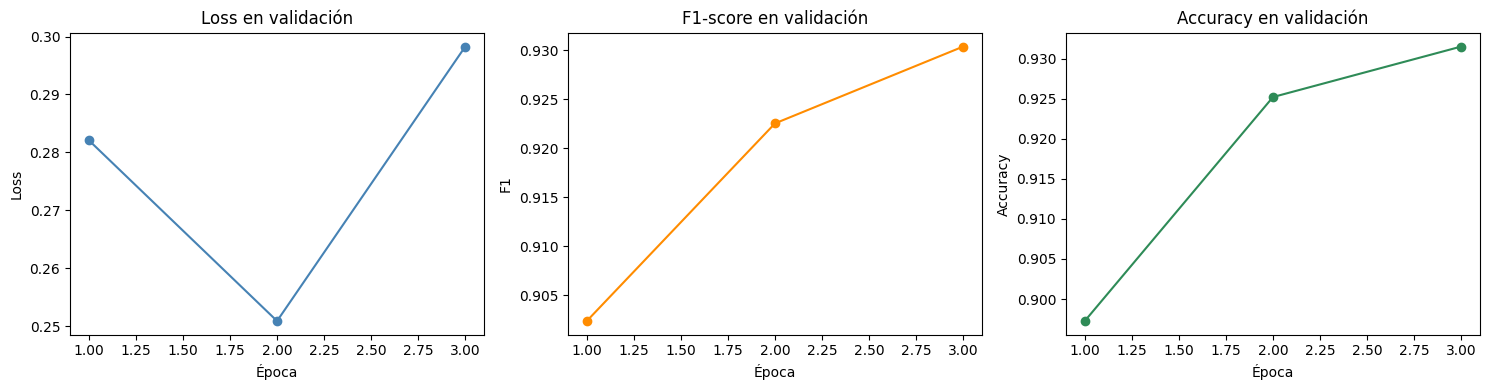

Guardada: curvas_entrenamiento.png


In [12]:
log_history = trainer.state.log_history

# Separar logs de entrenamiento y evaluación
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in log_history if "eval_loss" in x]

epochs_eval   = [x["epoch"]     for x in eval_logs]
eval_loss     = [x["eval_loss"] for x in eval_logs]
eval_f1       = [x["eval_f1"]   for x in eval_logs]
eval_accuracy = [x["eval_accuracy"] for x in eval_logs]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_eval, eval_loss, marker="o", color="steelblue")
axes[0].set_title("Loss en validación"); axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")

axes[1].plot(epochs_eval, eval_f1, marker="o", color="darkorange")
axes[1].set_title("F1-score en validación"); axes[1].set_xlabel("Época"); axes[1].set_ylabel("F1")

axes[2].plot(epochs_eval, eval_accuracy, marker="o", color="seagreen")
axes[2].set_title("Accuracy en validación"); axes[2].set_xlabel("Época"); axes[2].set_ylabel("Accuracy")

plt.tight_layout()
plt.savefig("curvas_entrenamiento.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardada: curvas_entrenamiento.png")


## 8. Evaluación en conjunto de prueba

In [13]:
test_results = trainer.evaluate(tokenized["test"])
print("\n📊 Resultados en test:")
for k, v in test_results.items():
    if k.startswith("eval_"):
        print(f"  {k[5:]:12s}: {v:.4f}")


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.075232,0.315179,3,0.928219,0.926570,0.929696,0.923464



📊 Resultados en test:
  loss        : 0.3152
  accuracy    : 0.9282
  f1          : 0.9266
  precision   : 0.9297
  recall      : 0.9235


In [14]:
preds_output = trainer.predict(tokenized["test"])
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

print("\n📋 Reporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=["Negativo", "Positivo"]))



📋 Reporte de clasificación:
              precision    recall  f1-score   support

    Negativo       0.93      0.93      0.93      1860
    Positivo       0.93      0.92      0.93      1790

    accuracy                           0.93      3650
   macro avg       0.93      0.93      0.93      3650
weighted avg       0.93      0.93      0.93      3650



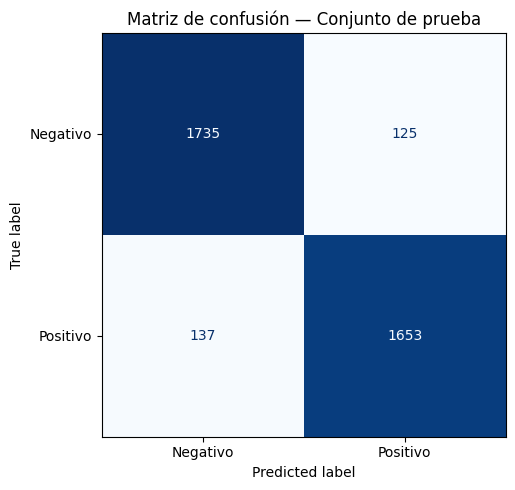

Guardada: matriz_confusion.png


In [15]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negativo", "Positivo"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusión — Conjunto de prueba")
plt.tight_layout()
plt.savefig("matriz_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardada: matriz_confusion.png")


## 9. Línea base — TF-IDF + Regresión Logística

In [16]:
train_texts = dataset["train"]["text"]
train_labels = dataset["train"]["label"]
test_texts  = dataset["test"]["text"]
test_labels = dataset["test"]["label"]

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)
X_train = tfidf.fit_transform(train_texts)
X_test  = tfidf.transform(test_texts)

lr = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
lr.fit(X_train, train_labels)
baseline_preds = lr.predict(X_test)

print("📊 Baseline TF-IDF + Regresión Logística:")
print(classification_report(test_labels, baseline_preds, target_names=["Negativo", "Positivo"]))


📊 Baseline TF-IDF + Regresión Logística:
              precision    recall  f1-score   support

    Negativo       0.88      0.89      0.89      1860
    Positivo       0.89      0.87      0.88      1790

    accuracy                           0.88      3650
   macro avg       0.88      0.88      0.88      3650
weighted avg       0.88      0.88      0.88      3650



## 10. Comparación DistilBERT vs Baseline

Métrica        DistilBERT    TF-IDF+LR     Mejora
--------------------------------------------------
Accuracy           0.9282       0.8827     +4.55%
F1-score           0.9266       0.8796     +4.70%
Precision          0.9297       0.8861     +4.36%
Recall             0.9235       0.8732     +5.03%


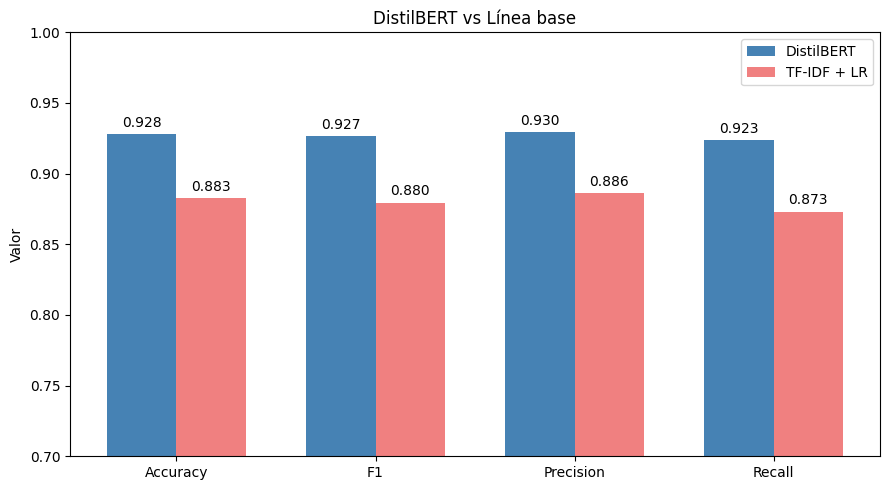

Guardada: comparacion_modelos.png


In [17]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

# DistilBERT
db_acc  = accuracy_score(y_true, y_pred)
db_f1   = f1_score(y_true, y_pred)
db_prec = precision_score(y_true, y_pred)
db_rec  = recall_score(y_true, y_pred)

# Baseline
bl_acc  = accuracy_score(test_labels, baseline_preds)
bl_f1   = f1_score(test_labels, baseline_preds)
bl_prec = precision_score(test_labels, baseline_preds)
bl_rec  = recall_score(test_labels, baseline_preds)

print(f"{'Métrica':<12} {'DistilBERT':>12} {'TF-IDF+LR':>12} {'Mejora':>10}")
print("-" * 50)
for metric, db, bl in [
    ("Accuracy",  db_acc,  bl_acc),
    ("F1-score",  db_f1,   bl_f1),
    ("Precision", db_prec, bl_prec),
    ("Recall",    db_rec,  bl_rec),
]:
    print(f"{metric:<12} {db:>12.4f} {bl:>12.4f} {(db-bl)*100:>+9.2f}%")

# Gráfico comparativo
metrics  = ["Accuracy", "F1", "Precision", "Recall"]
db_vals  = [db_acc, db_f1, db_prec, db_rec]
bl_vals  = [bl_acc, bl_f1, bl_prec, bl_rec]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, db_vals, width, label="DistilBERT", color="steelblue")
bars2 = ax.bar(x + width/2, bl_vals, width, label="TF-IDF + LR", color="lightcoral")
ax.set_ylim(0.7, 1.0)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel("Valor"); ax.set_title("DistilBERT vs Línea base")
ax.legend(); ax.bar_label(bars1, fmt="%.3f", padding=3); ax.bar_label(bars2, fmt="%.3f", padding=3)
plt.tight_layout()
plt.savefig("comparacion_modelos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardada: comparacion_modelos.png")


## 11. Análisis de errores

In [18]:
test_texts_list = dataset["test"]["text"]

errors = [
    {"text": test_texts_list[i], "true": y_true[i], "pred": y_pred[i]}
    for i in range(len(y_true))
    if y_true[i] != y_pred[i]
]

label_map = {0: "Negativo", 1: "Positivo"}
print(f"Total de errores: {len(errors)} / {len(y_true)} ({len(errors)/len(y_true)*100:.1f}%)")
print("\n--- Ejemplos de Falsos Positivos (predijo Positivo, era Negativo) ---")
fp = [e for e in errors if e["true"] == 0 and e["pred"] == 1]
for e in fp[:5]:
    print(f"  Texto: {e['text'][:120]}...")
    print()

print("--- Ejemplos de Falsos Negativos (predijo Negativo, era Positivo) ---")
fn = [e for e in errors if e["true"] == 1 and e["pred"] == 0]
for e in fn[:5]:
    print(f"  Texto: {e['text'][:120]}...")
    print()


Total de errores: 262 / 3650 (7.2%)

--- Ejemplos de Falsos Positivos (predijo Positivo, era Negativo) ---
  Texto: i loved iced cube back when he was with nwa but he really can't do comedy like he use to. he's more of a diverse father ...

  Texto: 'helen of troy' follows the story of helen and the outbreak of the trojan war. this is more of a love story between hele...

  Texto: if you're at the hospital and want something other than hospital food, this place may be the ticket. right across the st...

  Texto: everyone else who has commented negatively about this film have done excellent analysis as to why this film is so bloody...

  Texto: so we stayed here after deciding to come to vegas on a whim. i don't have much to say about it considering my boyfriend ...

--- Ejemplos de Falsos Negativos (predijo Negativo, era Positivo) ---
  Texto: i found this book extremely helpful and useful for helping me find a graduate school for my mba. i was a little disappoi...

  Texto: a movie ma

## 11.b. Busqueda de hiperparametros

Para cumplir con la estrategia de ajuste de hiperparametros exigida, se realiza
una busqueda en grilla (grid search) reducida sobre dos hiperparametros clave:
la tasa de aprendizaje (`learning_rate`) y el tamaño de lote (`batch_size`).

Cada combinacion se entrena por 1 epoca (para acelerar la busqueda) y se evalua
sobre el conjunto de **validacion** usando F1-score como metrica de seleccion.
El conjunto de prueba permanece aislado y NO se usa en esta etapa.

**Nota:** esta busqueda es un experimento de exploracion. El modelo final
reportado en las secciones anteriores usa la mejor configuracion encontrada
entrenada durante 3 epocas completas.


In [19]:
# Verificacion de seguridad: confirmar que se esta usando GPU antes del grid.
assert torch.cuda.is_available(), (
    'GPU NO detectada. Activa GPU en Entorno de ejecucion > Cambiar tipo '
    'de entorno de ejecucion > GPU T4 y vuelve a ejecutar desde arriba.'
)
print('GPU activa:', torch.cuda.get_device_name(0))

# Grid search reducido sobre learning_rate y batch_size.
# Se entrena 1 epoca por combinacion y se compara el F1 en validacion.
import time

# Grilla de hiperparametros a explorar
GRID_LEARNING_RATES = [2e-5, 3e-5, 5e-5]
GRID_BATCH_SIZES    = [16]        # batch fijo para aislar el efecto del learning rate

resultados_grid = []

for lr in GRID_LEARNING_RATES:
    for bs in GRID_BATCH_SIZES:
        print(f"\n=== Probando lr={lr} | batch_size={bs} ===")

        # Se reinicia el modelo desde el checkpoint preentrenado en cada corrida
        modelo_tmp = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=2,
            id2label={0: "NEGATIVE", 1: "POSITIVE"},
            label2id={"NEGATIVE": 0, "POSITIVE": 1},
        )

        args_tmp = TrainingArguments(
            output_dir                  = f"./grid_lr{lr}_bs{bs}",
            num_train_epochs            = 1,
            per_device_train_batch_size = bs,
            per_device_eval_batch_size  = bs,
            learning_rate               = lr,
            weight_decay                = WEIGHT_DECAY,
            warmup_ratio                = WARMUP_RATIO,
            eval_strategy               = "epoch",
            save_strategy               = "no",
            logging_steps               = 100,
            seed                        = SEED,
            report_to                   = "none",
            fp16                        = USE_GPU,
            disable_tqdm                = True,
        )

        trainer_tmp = Trainer(
            model            = modelo_tmp,
            args             = args_tmp,
            train_dataset    = tokenized["train"],
            eval_dataset     = tokenized["validation"],
            processing_class = tokenizer,
            data_collator    = data_collator,
            compute_metrics  = compute_metrics,
        )

        inicio = time.time()
        trainer_tmp.train()
        metrics_tmp = trainer_tmp.evaluate()
        duracion = time.time() - inicio

        resultados_grid.append({
            "learning_rate": lr,
            "batch_size": bs,
            "val_accuracy": metrics_tmp["eval_accuracy"],
            "val_f1": metrics_tmp["eval_f1"],
            "tiempo_s": round(duracion, 1),
        })

        # Liberar memoria de GPU antes de la siguiente combinacion
        del modelo_tmp, trainer_tmp
        if USE_GPU:
            torch.cuda.empty_cache()


GPU activa: Tesla T4

=== Probando lr=2e-05 | batch_size=16 ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


{'loss': '0.6803', 'grad_norm': '1.867', 'learning_rate': '1.082e-05', 'epoch': '0.05479'}
{'loss': '0.3897', 'grad_norm': '8.63', 'learning_rate': '1.981e-05', 'epoch': '0.1096'}
{'loss': '0.3004', 'grad_norm': '16.1', 'learning_rate': '1.859e-05', 'epoch': '0.1644'}
{'loss': '0.2889', 'grad_norm': '3.639', 'learning_rate': '1.737e-05', 'epoch': '0.2192'}
{'loss': '0.2837', 'grad_norm': '11.5', 'learning_rate': '1.615e-05', 'epoch': '0.274'}
{'loss': '0.2405', 'grad_norm': '3.209', 'learning_rate': '1.493e-05', 'epoch': '0.3288'}
{'loss': '0.2665', 'grad_norm': '8.87', 'learning_rate': '1.371e-05', 'epoch': '0.3836'}
{'loss': '0.2662', 'grad_norm': '3.841', 'learning_rate': '1.25e-05', 'epoch': '0.4384'}
{'loss': '0.2418', 'grad_norm': '7.869', 'learning_rate': '1.128e-05', 'epoch': '0.4932'}
{'loss': '0.2228', 'grad_norm': '4.768', 'learning_rate': '1.006e-05', 'epoch': '0.5479'}
{'loss': '0.2262', 'grad_norm': '9.295', 'learning_rate': '8.843e-06', 'epoch': '0.6027'}
{'loss': '0.233

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


{'loss': '0.6455', 'grad_norm': '4.224', 'learning_rate': '1.623e-05', 'epoch': '0.05479'}
{'loss': '0.3573', 'grad_norm': '9.522', 'learning_rate': '2.971e-05', 'epoch': '0.1096'}
{'loss': '0.3055', 'grad_norm': '15.69', 'learning_rate': '2.788e-05', 'epoch': '0.1644'}
{'loss': '0.2903', 'grad_norm': '2.305', 'learning_rate': '2.605e-05', 'epoch': '0.2192'}
{'loss': '0.2939', 'grad_norm': '7.367', 'learning_rate': '2.423e-05', 'epoch': '0.274'}
{'loss': '0.2371', 'grad_norm': '11.02', 'learning_rate': '2.24e-05', 'epoch': '0.3288'}
{'loss': '0.2621', 'grad_norm': '7.685', 'learning_rate': '2.057e-05', 'epoch': '0.3836'}
{'loss': '0.2752', 'grad_norm': '3.039', 'learning_rate': '1.875e-05', 'epoch': '0.4384'}
{'loss': '0.2422', 'grad_norm': '5.6', 'learning_rate': '1.692e-05', 'epoch': '0.4932'}
{'loss': '0.2215', 'grad_norm': '4.068', 'learning_rate': '1.509e-05', 'epoch': '0.5479'}
{'loss': '0.2289', 'grad_norm': '9.373', 'learning_rate': '1.326e-05', 'epoch': '0.6027'}
{'loss': '0.2

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


{'loss': '0.6096', 'grad_norm': '5.831', 'learning_rate': '2.705e-05', 'epoch': '0.05479'}
{'loss': '0.3547', 'grad_norm': '9.22', 'learning_rate': '4.951e-05', 'epoch': '0.1096'}
{'loss': '0.3356', 'grad_norm': '17.04', 'learning_rate': '4.647e-05', 'epoch': '0.1644'}
{'loss': '0.3181', 'grad_norm': '2.208', 'learning_rate': '4.342e-05', 'epoch': '0.2192'}
{'loss': '0.3098', 'grad_norm': '5.631', 'learning_rate': '4.038e-05', 'epoch': '0.274'}
{'loss': '0.2539', 'grad_norm': '6.448', 'learning_rate': '3.733e-05', 'epoch': '0.3288'}
{'loss': '0.2752', 'grad_norm': '6.396', 'learning_rate': '3.429e-05', 'epoch': '0.3836'}
{'loss': '0.2837', 'grad_norm': '1.936', 'learning_rate': '3.124e-05', 'epoch': '0.4384'}
{'loss': '0.2582', 'grad_norm': '3.083', 'learning_rate': '2.82e-05', 'epoch': '0.4932'}
{'loss': '0.2343', 'grad_norm': '2.649', 'learning_rate': '2.515e-05', 'epoch': '0.5479'}
{'loss': '0.2305', 'grad_norm': '6.689', 'learning_rate': '2.211e-05', 'epoch': '0.6027'}
{'loss': '0.

 learning_rate  batch_size  val_accuracy    val_f1  tiempo_s
------------------------------------------------------------
         3e-05          16        0.9227    0.9199     351.5
         5e-05          16        0.9222    0.9193     351.5
         2e-05          16        0.9208    0.9183     353.0

Mejor configuracion encontrada:
  learning_rate = 3e-05
  batch_size    = 16
  F1 validacion = 0.9199


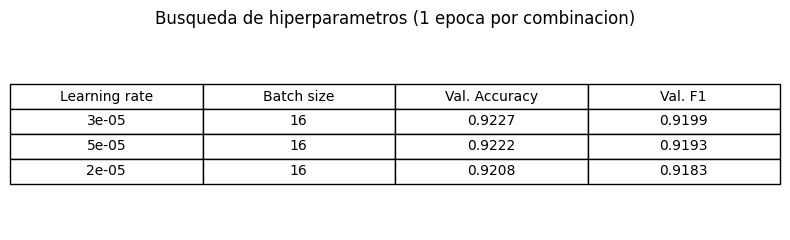

Guardada: busqueda_hiperparametros.png


In [20]:
# Tabla resumen de la busqueda de hiperparametros, ordenada por F1 en validacion
resultados_ordenados = sorted(resultados_grid, key=lambda r: r["val_f1"], reverse=True)

print(f"{'learning_rate':>14} {'batch_size':>11} {'val_accuracy':>13} {'val_f1':>9} {'tiempo_s':>9}")
print("-" * 60)
for r in resultados_ordenados:
    print(f"{r['learning_rate']:>14} {r['batch_size']:>11} "
          f"{r['val_accuracy']:>13.4f} {r['val_f1']:>9.4f} {r['tiempo_s']:>9}")

mejor = resultados_ordenados[0]
print("\nMejor configuracion encontrada:")
print(f"  learning_rate = {mejor['learning_rate']}")
print(f"  batch_size    = {mejor['batch_size']}")
print(f"  F1 validacion = {mejor['val_f1']:.4f}")

# Guardar la tabla como imagen para incluirla en el informe
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis("off")
tabla_datos = [[r['learning_rate'], r['batch_size'],
                f"{r['val_accuracy']:.4f}", f"{r['val_f1']:.4f}"]
               for r in resultados_ordenados]
tabla = ax.table(
    cellText=tabla_datos,
    colLabels=["Learning rate", "Batch size", "Val. Accuracy", "Val. F1"],
    loc="center", cellLoc="center",
)
tabla.auto_set_font_size(False); tabla.set_fontsize(10); tabla.scale(1, 1.5)
ax.set_title("Busqueda de hiperparametros (1 epoca por combinacion)", pad=10)
plt.tight_layout()
plt.savefig("busqueda_hiperparametros.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardada: busqueda_hiperparametros.png")


## 12. Guardar modelo (opcional)

In [21]:
# Guardar localmente
trainer.save_model("./distilbert-sentiment-final")
tokenizer.save_pretrained("./distilbert-sentiment-final")
print("Modelo guardado en ./distilbert-sentiment-final")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en ./distilbert-sentiment-final


## 13. Resumen para el informe

In [22]:
print("=" * 55)
print("  RESUMEN DE RESULTADOS — ENTREGABLE 2")
print("=" * 55)
print(f"  Modelo        : {MODEL_NAME}")
print(f"  Dataset       : Drocho/sentiment-unified")
print(f"  Max tokens    : {MAX_LENGTH}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Learning rate : {LEARNING_RATE}")
print(f"  Épocas        : {NUM_EPOCHS}")
print("-" * 55)
print(f"  {'Métrica':<12} {'DistilBERT':>12} {'Baseline':>12}")
print(f"  {'-'*38}")
for metric, db, bl in [
    ("Accuracy",  db_acc,  bl_acc),
    ("F1-score",  db_f1,   bl_f1),
    ("Precision", db_prec, bl_prec),
    ("Recall",    db_rec,  bl_rec),
]:
    print(f"  {metric:<12} {db:>12.4f} {bl:>12.4f}")
print("=" * 55)
print("Imágenes generadas:")
print("  - curvas_entrenamiento.png")
print("  - matriz_confusion.png")
print("  - comparacion_modelos.png")


  RESUMEN DE RESULTADOS — ENTREGABLE 2
  Modelo        : distilbert-base-uncased
  Dataset       : Drocho/sentiment-unified
  Max tokens    : 512
  Batch size    : 16
  Learning rate : 2e-05
  Épocas        : 3
-------------------------------------------------------
  Métrica        DistilBERT     Baseline
  --------------------------------------
  Accuracy           0.9282       0.8827
  F1-score           0.9266       0.8796
  Precision          0.9297       0.8861
  Recall             0.9235       0.8732
Imágenes generadas:
  - curvas_entrenamiento.png
  - matriz_confusion.png
  - comparacion_modelos.png
